# Instagram Influencers Data Analysis

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

## Load Dataset

In [4]:
df = pd.read_csv('../dataset/top_instagram_influencers_data.csv')

df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country,followers_numeric,avg_likes_numeric,new_post_avg_like_numeric,total_likes_numeric
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain,475800000,8700000,6500000,29000000000
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States,366200000,8300000,5900000,57400000000
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN,357300000,6800000,4400000,6000000000
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States,342700000,6200000,3300000,11500000000
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States,334100000,1900000,665300,12500000000


## Dataset Information

In [6]:
print("Shape:", df.shape)

df.info()

Shape: (200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   rank                       200 non-null    int64 
 1   channel_info               200 non-null    object
 2   influence_score            200 non-null    int64 
 3   posts                      200 non-null    object
 4   followers                  200 non-null    object
 5   avg_likes                  200 non-null    object
 6   60_day_eng_rate            200 non-null    object
 7   new_post_avg_like          200 non-null    object
 8   total_likes                200 non-null    object
 9   country                    138 non-null    object
 10  followers_numeric          200 non-null    int64 
 11  avg_likes_numeric          200 non-null    int64 
 12  new_post_avg_like_numeric  200 non-null    int64 
 13  total_likes_numeric        200 non-null    int64

## Check Missing Values

In [7]:
df.isnull().sum()

rank                          0
channel_info                  0
influence_score               0
posts                         0
followers                     0
avg_likes                     0
60_day_eng_rate               0
new_post_avg_like             0
total_likes                   0
country                      62
followers_numeric             0
avg_likes_numeric             0
new_post_avg_like_numeric     0
total_likes_numeric           0
dtype: int64

## Data Cleaning

In [8]:
def convert_to_number(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).lower().strip()
    
    if 'b' in x:
        return float(x.replace('b','')) * 1_000_000_000
    
    elif 'm' in x:
        return float(x.replace('m','')) * 1_000_000
    
    elif 'k' in x:
        return float(x.replace('k','')) * 1_000
    
    else:
        try:
            return float(x)
        except:
            return np.nan

df['followers_numeric'] = df['followers'].apply(convert_to_number)
df['avg_likes_numeric'] = df['avg_likes'].apply(convert_to_number)
df['new_post_avg_like_numeric'] = df['new_post_avg_like'].apply(convert_to_number)
df['total_likes_numeric'] = df['total_likes'].apply(convert_to_number)

df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country,followers_numeric,avg_likes_numeric,new_post_avg_like_numeric,total_likes_numeric
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain,475800000.0,8700000.0,6500000.0,2.900000e+10
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States,366200000.0,8300000.0,5900000.0,5.740000e+10
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN,357300000.0,6800000.0,4400000.0,6.000000e+09
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States,342700000.0,6200000.0,3300000.0,1.150000e+10
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States,334100000.0,1900000.0,665300.0,1.250000e+10


## Statistical Summary

In [9]:
df.describe()

,rank,influence_score,followers_numeric,avg_likes_numeric,new_post_avg_like_numeric,total_likes_numeric
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,100.500000,81.820000,7.740950e+07,1.787104e+06,1.208132e+06,3.658112e+09
std,57.879185,8.878159,7.368727e+07,2.193359e+06,1.858322e+06,5.561939e+09
min,1.000000,22.000000,3.280000e+07,6.510000e+04,0.000000e+00,1.830000e+07
25%,50.750000,80.000000,4.000000e+07,5.044000e+05,1.957500e+05,9.968500e+08
50%,100.500000,84.000000,5.005000e+07,1.100000e+06,5.321500e+05,2.000000e+09
75%,150.250000,86.000000,6.890000e+07,2.100000e+06,1.325000e+06,3.900000e+09
max,200.000000,93.000000,4.758000e+08,1.540000e+07,1.260000e+07,5.740000e+10


## Top 10 Influencers by Followers

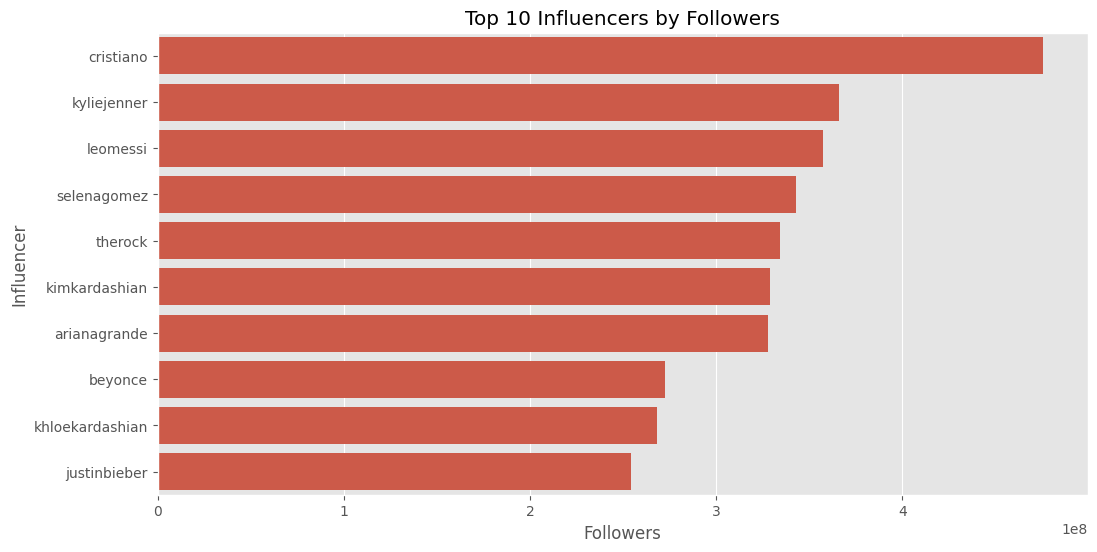

In [10]:
top_followers = df.sort_values(by='followers_numeric', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=top_followers,
            x='followers_numeric',
            y='channel_info')

plt.title('Top 10 Influencers by Followers')
plt.xlabel('Followers')
plt.ylabel('Influencer')

plt.show()

## Most Active Influencers

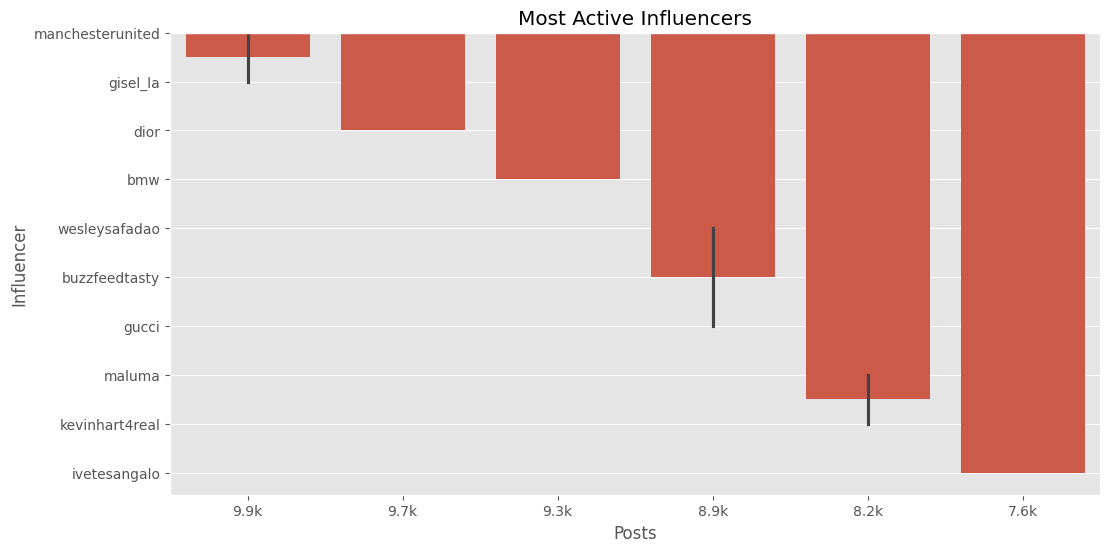

In [11]:
most_active = df.sort_values(by='posts', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(data=most_active,
            x='posts',
            y='channel_info')

plt.title('Most Active Influencers')
plt.xlabel('Posts')
plt.ylabel('Influencer')

plt.show()

## Country-wise Influencer Distribution

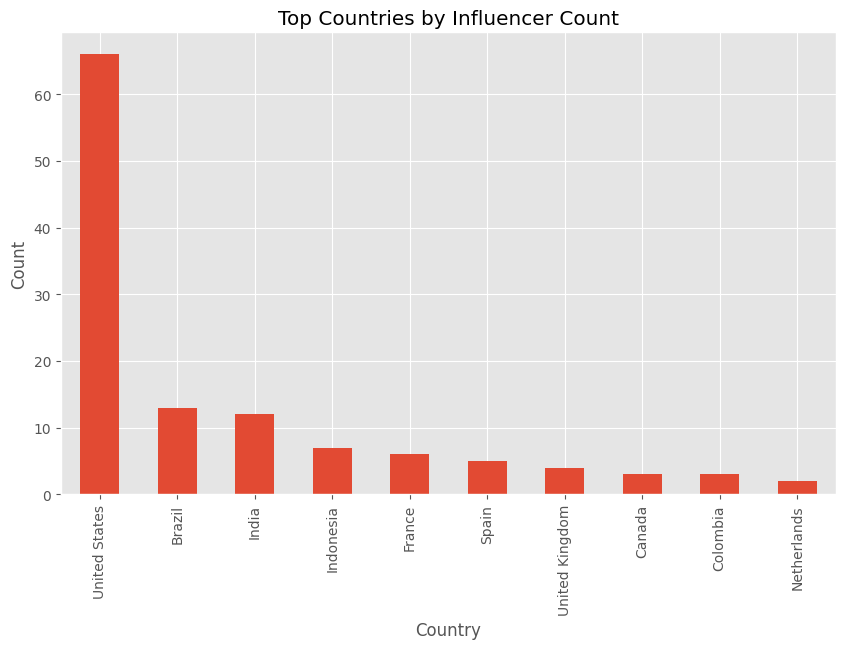

In [12]:
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

country_counts.plot(kind='bar')

plt.title('Top Countries by Influencer Count')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

## Followers vs Posts Relationship

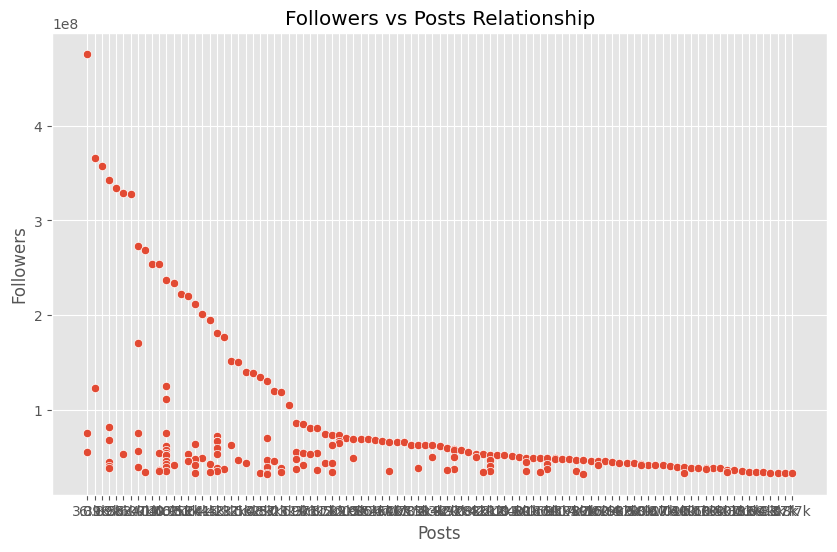

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x='posts',
                y='followers_numeric')

plt.title('Followers vs Posts Relationship')
plt.xlabel('Posts')
plt.ylabel('Followers')

plt.show()

## Followers vs Average Likes

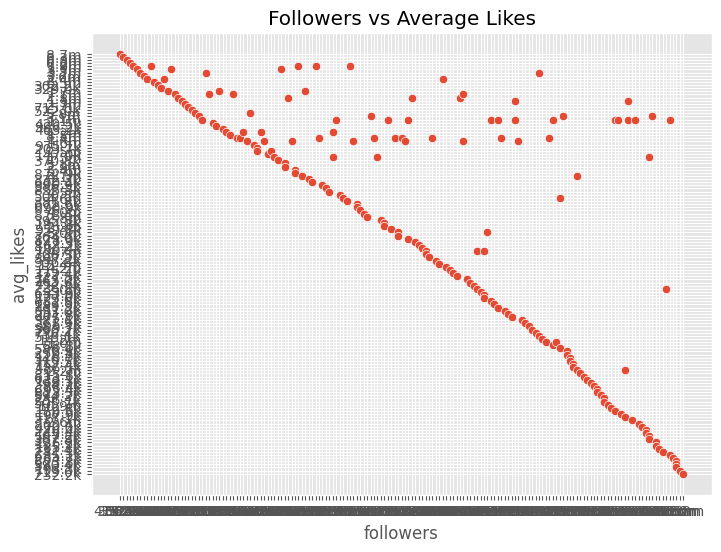

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='followers', y='avg_likes')
plt.title("Followers vs Average Likes")
plt.show()

## Key Insights

1. Cristiano Ronaldo and Kylie Jenner have the highest followers.
2. United States has the highest influencer count.
3. Top influencers generate billions of likes.
4. Posting activity does not always guarantee higher followers.
5. Followers and likes have a strong positive relationship.


## Conclusion

This project demonstrates:
- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Dashboard Building
- Insight Generation
